# **Trabajo Práctico 1 - Parte 2 - Juego: Pradera**
---
## ***Procesamiento del Lenguaje Natural - TUIA***

| Autora | Legajo |
| --- | --- |
Rizzotto, María Camila | R-4676/1

# Ejercicio 1 - Carga de Repositorio

In [1]:
from googleapiclient.discovery import build
from googleapiclient.http import MediaIoBaseDownload
from google.colab import auth
import io
import os

# Autenticar
auth.authenticate_user()
drive_service = build('drive', 'v3')

# ID de la carpeta en Drive con los datos del juego PRADERA
FOLDER_ID = '1bQazMZnk73rRaG5btORykstehZABNf-C'
DESTINO_LOCAL = '/content/datos_pradera'

# Crear carpeta local si no existe
os.makedirs(DESTINO_LOCAL, exist_ok=True)

# Función recursiva para descargar carpetas con subcarpetas
def descargar_carpeta(folder_id, ruta_destino):
    query = f"'{folder_id}' in parents and trashed=false"
    resultados = drive_service.files().list(q=query, fields="files(id, name, mimeType)").execute()
    items = resultados.get('files', [])

    for item in items:
        nombre = item['name']
        file_id = item['id']
        tipo = item['mimeType']

        if tipo == 'application/vnd.google-apps.folder':
            # Es una subcarpeta
            nueva_ruta = os.path.join(ruta_destino, nombre)
            os.makedirs(nueva_ruta, exist_ok=True)
            descargar_carpeta(file_id, nueva_ruta)
        else:
            # Es un archivo, lo descargamos
            request = drive_service.files().get_media(fileId=file_id)
            fh = io.FileIO(os.path.join(ruta_destino, nombre), 'wb')
            downloader = MediaIoBaseDownload(fh, request)
            done = False
            while not done:
                status, done = downloader.next_chunk()

# Ejecutar la descarga
descargar_carpeta(FOLDER_ID, DESTINO_LOCAL)
print(f"✅ Carpeta descargada con subcarpetas en: {DESTINO_LOCAL}")

✅ Carpeta descargada con subcarpetas en: /content/datos_pradera


#Ejercicio 2

Para este apartado, voy a utilizar el texto extraído denominado *'Mecanica_del_juego.txt'* del apartado de **información** del repositorio que me tocó.

##Fragmentación de texto

In [2]:
%%capture
!python -m spacy download es_core_news_sm
import spacy
from spacy import displacy

In [3]:
# Separación del texto en oraciones
text = open('/content/datos_pradera/informacion/Mecanica_del_juego.txt', 'r').read()

# Cargar el modelo spaCy de español
nlp = spacy.load("es_core_news_sm")

# Procesar el texto
doc = nlp(text)

# Extraer las oraciones
sentences = [sent.text.strip() for sent in doc.sents if sent.text.strip()]
for sent in sentences[:10]:
    displacy.render(nlp(sent),style='ent',jupyter=True)

/usr/local/lib/python3.11/dist-packages/spacy/displacy/__init__.py:213: UserWarning: [W006] No entities to visualize found in Doc object. If this is surprising to you, make sure the Doc was processed using a model that supports named entity recognition, and check the `doc.ents` property manually if necessary.
  warnings.warn(Warnings.W006)


##Análisis de Similitud

###Embbeding y búsqueda semántica

Voy a utilizar el modelo pre-entrenado MS Marco para realizar las búsquedas semánticas. A partir de una consulta, genero su embedding, lo comparo contra las embeddings de un corpus de oraciones usando similitud del coseno, y devuelvo el top 3 de frases más cercanas en significado.


In [4]:
%%capture
!pip install sentence-transformers

In [7]:
from sentence_transformers import SentenceTransformer, util

# Cargar el modelo pre-entrenado
modelo = SentenceTransformer('msmarco-MiniLM-L-6-v3')

def buscar_similaridad(frase_consulta, sentences, modelo=modelo):

    # Generar incrustaciones para la consulta y respuestas
    incrustaciones_consulta = modelo.encode([frase_consulta])
    incrustaciones_respuestas = modelo.encode(sentences)

    # Buscar top-3 respuestas similares
    hits = util.semantic_search(incrustaciones_consulta, incrustaciones_respuestas, top_k=3)

    print(f"Consulta: {frase_consulta}")
    for j, hit in enumerate(hits[0]):
        print(f"Respuesta {j+1} (Similitud: {hit['score']:.4f}): {sentences[hit['corpus_id']]}")
    print()

    return hits

In [8]:
print("-- Query 1 --")
hits_1 = buscar_similaridad("explica la mecánica del juego", sentences)

print("\n-- Query 2 --")
hits_2 = buscar_similaridad("el jugador que gana", sentences)

print("\n-- Query 3 --")
hits_3 = buscar_similaridad("la regla del juego", sentences)

print("\n-- Query 4 --")
hits_4 = buscar_similaridad("en cada ronda", sentences)

print("\n-- Query 5 --")
hits_5 = buscar_similaridad("termina el juego cuando", sentences)

-- Query 1 --
Consulta: explica la mecánica del juego
Respuesta 1 (Similitud: 0.6483): Como he dicho, la mecánica principal del juego es el draft, ya que los jugadores deberán ir colocando en su zona de juego cartas intentando maximizar la cantidad de puntos que estas proporcionan.
Respuesta 2 (Similitud: 0.5896): Juego en Solitario.
Respuesta 3 (Similitud: 0.5421): En el juego de François Gandon este mecanismo funcionaba a las mil maravillas porque introducía una potente gestión de los tiempos que, salvando las distancias, rememora sensaciones similares a las que recibimos en juegos con mecánica de colocación de trabajadores, aunque sin la complejidad de tener que evaluar mentalmente qué opción disponible es la más interesante.


-- Query 2 --
Consulta: el jugador que gana
Respuesta 1 (Similitud: 0.6921): A dos jugadores el número de símbolos es menor y ese punto de influencia del azar puede afectar algo más a la hora de competir por estas parejas.
Respuesta 2 (Similitud: 0.6876): Es 

### Técnicas de distancias

Voy a usar diferentes técnicas de distancias (Jaccard, Levenshtein, y Dice) para ver qué oraciones encuentran.

In [10]:
%%capture
!pip install python-Levenshtein

In [11]:
import Levenshtein
import numpy as np

# Funciones de similitud
def jaccard_sim(str1, str2):
    set1, set2 = set(str1.lower().split()), set(str2.lower().split())
    interseccion = set1.intersection(set2)
    union = set1.union(set2)
    return len(interseccion) / len(union) if union else 0

def dice_sim(str1, str2):
    set1, set2 = set(str1.lower().split()), set(str2.lower().split())
    interseccion = set1.intersection(set2)
    return 2 * len(interseccion) / (len(set1) + len(set2)) if (len(set1) + len(set2)) else 0

def levenshtein_sim(str1, str2):
    return Levenshtein.ratio(str1, str2)

# Función principal
def comparar_similitudes_textuales(query, oraciones, top_k=3):
    resultados = []

    for oracion in oraciones:
        resultados.append({
            "oracion": oracion,
            "jaccard": jaccard_sim(query, oracion),
            "dice": dice_sim(query, oracion),
            "levenshtein": levenshtein_sim(query, oracion)
        })

    # Mostrar top-k de cada métrica
    print(f"Frase de consulta: '{query}'\n")
    for metrica in ["jaccard", "dice", "levenshtein"]:
        print(f"Top {top_k} frases más similares según {metrica.capitalize()}:")
        top_frases = sorted(resultados, key=lambda x: x[metrica], reverse=True)[:top_k]
        for i, f in enumerate(top_frases, 1):
            print(f"  {i}. ({f[metrica]:.4f}) {f['oracion']}")
        print()

In [6]:
comparar_similitudes_textuales("explica la mecánica del juego", sentences)

Frase de consulta: 'explica la mecánica del juego'

Top 3 frases más similares según Jaccard:
  1. (0.1429) Juego en Solitario.
  2. (0.1333) Como he dicho, la mecánica principal del juego es el draft, ya que los jugadores deberán ir colocando en su zona de juego cartas intentando maximizar la cantidad de puntos que estas proporcionan.
  3. (0.1333) En cuanto a la escalabilidad, el juego funciona perfectamente en todas sus configuraciones.

Top 3 frases más similares según Dice:
  1. (0.2500) Juego en Solitario.
  2. (0.2353) Como he dicho, la mecánica principal del juego es el draft, ya que los jugadores deberán ir colocando en su zona de juego cartas intentando maximizar la cantidad de puntos que estas proporcionan.
  3. (0.2353) En cuanto a la escalabilidad, el juego funciona perfectamente en todas sus configuraciones.

Top 3 frases más similares según Levenshtein:
  1. (0.4167) Pasemos a la producción, otro aspecto bastante cuidado en el juego.
  2. (0.3797) La partida finaliza al 

Se ve que Dice encontró en segundo lugar la misma que la obtenida por la similitud del coseno. Veamos un par más:

In [12]:
comparar_similitudes_textuales("el jugador que gana", sentences)

Frase de consulta: 'el jugador que gana'

Top 3 frases más similares según Jaccard:
  1. (0.1429) Cada jugador calcula su puntuación sumando:
El jugador con más puntos será el vencedor.
  2. (0.1429) En caso de empate, el jugador con más cartas de descubrimiento será el vencedor.
  3. (0.1250) Creo que Karolina ha esgrimido razones artísticas (por no dejar demasiado desnudo el tablero).

Top 3 frases más similares según Dice:
  1. (0.2500) Cada jugador calcula su puntuación sumando:
El jugador con más puntos será el vencedor.
  2. (0.2500) En caso de empate, el jugador con más cartas de descubrimiento será el vencedor.
  3. (0.2222) Creo que Karolina ha esgrimido razones artísticas (por no dejar demasiado desnudo el tablero).

Top 3 frases más similares según Levenshtein:
  1. (0.3889) Y vamos cerrando.
  2. (0.3846) Si el empate persiste, los jugadores comparten la victoria.
  3. (0.3721) Por todo esto le doy un…



In [13]:
comparar_similitudes_textuales("la regla del juego", sentences)

Frase de consulta: 'la regla del juego'

Top 3 frases más similares según Jaccard:
  1. (0.1667) Juego en Solitario.
  2. (0.1429) En cuanto a la escalabilidad, el juego funciona perfectamente en todas sus configuraciones.
  3. (0.1176) A nivel de diseño el juego es bastante funcional y la simbología se asimila fácilmente.

Top 3 frases más similares según Dice:
  1. (0.2857) Juego en Solitario.
  2. (0.2500) En cuanto a la escalabilidad, el juego funciona perfectamente en todas sus configuraciones.
  3. (0.2105) A nivel de diseño el juego es bastante funcional y la simbología se asimila fácilmente.

Top 3 frases más similares según Levenshtein:
  1. (0.3944) Donde de verdad brilla el juego es a nivel artístico.
  2. (0.3765) Pasemos a la producción, otro aspecto bastante cuidado en el juego.
  3. (0.3429) Y vamos cerrando.



Se ve claramente que Dice y Jaccard obtienen los mismos resultados, pero Dice los pondera más significativamente. Las oraciones que extrae Levenshtein no tienen que ver con la query, más allá de coincidir en alguna palabra.  
No parece que estas otras técnicas de distancia acompañen bien a lo que es una búsqueda semántica. Vamos a visualizarlo con t SNE:

In [ ]:
!pip install plotly scikit-learn

In [21]:
from sklearn.manifold import TSNE
import plotly.express as px
import pandas as pd

def visualizar_tsne(query, oraciones, resultados, modelo_name='msmarco-MiniLM-L-6-v3'):
    frases = [query] + oraciones
    etiquetas = []

    for frase in frases:
        if frase == query:
            etiquetas.append("Query")
        elif frase == resultados.get("Coseno"):
            etiquetas.append("Coseno")
        elif frase == resultados.get("Dice"):
            etiquetas.append("Dice")
        elif frase == resultados.get("Levenshtein"):
            etiquetas.append("Levenshtein")
        else:
            etiquetas.append("Oración")

    # Embeddings
    modelo = SentenceTransformer(modelo_name)
    embeddings = modelo.encode(frases)

    # Ajustar perplexity
    perplexity = min(5, len(frases) - 1)

    # t-SNE a 3 dimensiones
    tsne = TSNE(n_components=3, random_state=42, perplexity=perplexity)
    puntos_3d = tsne.fit_transform(embeddings)

    # DataFrame
    df = pd.DataFrame(puntos_3d, columns=["x", "y", "z"])
    df["frase"] = frases
    df["tipo"] = etiquetas

    # Visualización
    fig = px.scatter_3d(
        df,
        x='x', y='y', z='z',
        color='tipo',
        hover_name='frase',
        symbol='tipo',
        size=[14 if t == "Query" else 10 for t in df["tipo"]],
        opacity=0.85
    )
    fig.update_traces(marker=dict(line=dict(width=1, color='DarkSlateGrey')))
    fig.update_layout(title="t-SNE 3D: Todas las frases con técnicas destacadas", width=950, height=700)
    fig.show()

In [22]:
query = "explica la mecánica del juego"

resultados = {
    "Coseno": "Como he dicho, la mecánica principal del juego es el draft, ya que los jugadores deberán ir colocando en su zona de juego cartas intentando maximizar la cantidad de puntos que estas proporcionan.",
    "Dice": "Juego en Solitario.",
    "Levenshtein": "Pasemos a la producción, otro aspecto bastante cuidado en el juego."
}

visualizar_tsne(query, sentences, resultados)

Basándome en una de mis querys, con este visualizador se puede ver claramente que las últimas técnicas de distancias vistas encuentran oraciones que están más alejadas en cuanto al sentido semántico de la frase consultada.

##Conclusiones

Siendo mi objetivo recuperar la oración más relevante de un texto extenso dada una consulta, es decir encontrar frases con similar sentido semántico que la query, la similitud del coseno sobre embeddings densos es la métrica más adecuada. Las métricas basadas en tokens (Jaccard, Dice) pueden captar alguna relación si hay palabras comunes (Dice sindo más sensible a coincidencias que Jaccard), pero no reconocen sinónimos ni construcciones equivalentes. Levenshtein, al basarse en caracteres, no es útil para textos con vocabulario diferente pero mismo significado. Estos resultados eran esperados porque estas últimas tres medidas se centran en buscar oraciones similares basándose en el la estructura de las frases y su sentido literal, no semántico como lo pedido en el problema, por lo que su uso no es acorde. A lo sumo, por los resultados que obtuve, preferiría acompañar mis búsquedas con Dice para encontrar similitudes más literales y coincidencias

#Ejercicio 3

Para este ejercicio, vamos a aprovechar el texto que ya trabajamos con spacy y vemos:

In [28]:
!python -m spacy download es_core_news_lg

nlp2 = spacy.load("es_core_news_lg")

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 568.0/568.0 MB 856.4 kB/s eta 0:00:00
✔ Download and installation successful
You can now load the package via spacy.load('es_core_news_lg')
⚠ Restart to reload dependencies
If you are in a Jupyter or Colab notebook, you may need to restart Python in
order to load all the package's dependencies. You can do this by selecting the
'Restart kernel' or 'Restart runtime' option.


##Extracción POS y categorización NER

In [61]:
for i, frase in enumerate(sentences):
    doc = nlp2(frase)

    print(f"\n🟦 Frase {i+1}: {frase}")

    # Extraer todos los sustantivos: comunes y propios
    sustantivos = [token for token in doc if token.pos_ in {"NOUN", "PROPN"}]
    print(f"  - Sustantivos (POS): {[token.text for token in sustantivos]}")

    # Buscar entidades nombradas que incluyan uno o más de esos sustantivos
    entidades_en_sustantivos = []
    for ent in doc.ents:
        for token in sustantivos:
            if token.text in ent.text:
                entidades_en_sustantivos.append((ent.text, ent.label_, spacy.explain(ent.label_)))
                break  # Evita agregar la misma entidad varias veces

    if entidades_en_sustantivos:
        print("  - Entidades nombradas dentro de los sustantivos (NER):")
        for texto, etiqueta, explicacion in entidades_en_sustantivos:
            print(f"    • {texto} ({etiqueta}): {explicacion}")
    else:
        print("  - Entidades nombradas dentro de los sustantivos (NER): Ninguna encontrada.")


🟦 Frase 1: Conviértete en un explorador que compite con otros por ver quién es el observador de la naturaleza más hábil en un viaje para el que no se necesita más que el deseo por descubrir los misterios de la naturaleza y una mirada llena de curiosidad por cada pequeño detalle que nos encontremos en el camino.
  - Sustantivos (POS): ['Conviértete', 'explorador', 'observador', 'naturaleza', 'viaje', 'deseo', 'misterios', 'naturaleza', 'mirada', 'curiosidad', 'detalle', 'camino']
  - Entidades nombradas dentro de los sustantivos (NER): Ninguna encontrada.

🟦 Frase 2: Así se nos presenta Pradera, diseñado por Klemens Kalicki, responsable de Dream Home.
  - Sustantivos (POS): ['Pradera', 'Klemens', 'Kalicki', 'responsable', 'Dream', 'Home']
  - Entidades nombradas dentro de los sustantivos (NER):
    • Pradera (LOC): Non-GPE locations, mountain ranges, bodies of water
    • Klemens Kalicki (PER): Named person or family.
    • Dream Home (MISC): Miscellaneous entities, e.g. events, nation

##Búsqueda de Similitud

Voy a realizar una función a la que se le pueda ingresar una query, de ella se extraerán los sustantivos y finalmente se obtendrán oraciones de acuerdo a diferentes búsquedas de distancias. Para este ejercicio ya dejo de lado a Jaccard quedándome sólo con Dice, e incorporo a Jaro-Winkler

In [63]:
!pip install jellyfish

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 356.9/356.9 kB 5.7 MB/s eta 0:00:00


In [64]:
import jellyfish
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.metrics.pairwise import cosine_similarity

In [72]:
def dice_sim(set1, set2):
    interseccion = set1 & set2
    return 2 * len(interseccion) / (len(set1) + len(set2)) if (len(set1) + len(set2)) else 0

def levenshtein_sim(set1, set2):
    str1, str2 = " ".join(set1), " ".join(set2)
    return Levenshtein.ratio(str1, str2)

def jaro_winkler_sim(set1, set2):
    str1, str2 = " ".join(set1), " ".join(set2)
    return jellyfish.jaro_winkler_similarity(str1, str2)

def coseno_sim(query_str, frases_strs):
    vectorizer = TfidfVectorizer()
    vectores = vectorizer.fit_transform([query_str] + frases_strs)
    similitudes = cosine_similarity(vectores[0:1], vectores[1:]).flatten()
    return similitudes

#Función para extraer los sustantivos de mi query
def extraer_sustantivos(texto, mostrar_result=True):
    doc = nlp(texto)
    sustantivos = {token.text.lower() for token in doc if token.pos_ in {"NOUN", "PROPN"}}
    if mostrar_result:
      if sustantivos:
        print(f"Sustantivos extraídos de: “{texto}”\n   → {sorted(sustantivos)}\n")
      else:
        print(f"No se encontraron sustantivos en la query ingresada\n")
    return sustantivos

def buscar_similitud_por_sustantivos(query, sentences, top_n=3):
    sustantivos_query = extraer_sustantivos(query)
    str_query = " ".join(sustantivos_query)

    frases_strs = []
    resultados = []

    for frase in sentences:
        sustantivos_frase = extraer_sustantivos(frase, False)
        str_frase = " ".join(sustantivos_frase)
        frases_strs.append(str_frase)
        resultados.append({
            "frase": frase,
            "dice": dice_sim(sustantivos_query, sustantivos_frase),
            "levenshtein": levenshtein_sim(sustantivos_query, sustantivos_frase),
            "jaro_winkler": jaro_winkler_sim(sustantivos_query, sustantivos_frase),
            "coseno_str": str_frase  # temporal, para calcular luego en bloque
        })

    # Calcular similitud del coseno por lotes
    cos_sim_scores = coseno_sim(str_query, [r["coseno_str"] for r in resultados])
    for i, sim in enumerate(cos_sim_scores):
        resultados[i]["coseno"] = sim
        del resultados[i]["coseno_str"]  # limpiar

    for metodo in ["dice", "levenshtein", "jaro_winkler", "coseno"]:
        print(f"\nTop {top_n} frases según {metodo.upper()}:\n")
        frases_ordenadas = sorted(resultados, key=lambda x: x[metodo], reverse=True)
        for r in frases_ordenadas[:top_n]:
            print(f"- Similitud: {r[metodo]:.4f} | Frase: {r['frase']}")

In [84]:
buscar_similitud_por_sustantivos("Prafera", sentences)

Sustantivos extraídos de: “Prafera”
   → ['prafera']


Top 3 frases según DICE:

- Similitud: 0.0000 | Frase: Conviértete en un explorador que compite con otros por ver quién es el observador de la naturaleza más hábil en un viaje para el que no se necesita más que el deseo por descubrir los misterios de la naturaleza y una mirada llena de curiosidad por cada pequeño detalle que nos encontremos en el camino.
- Similitud: 0.0000 | Frase: Así se nos presenta Pradera, diseñado por Klemens Kalicki, responsable de Dream Home.
- Similitud: 0.0000 | Frase: El juego fue publicado en 2021 por Rebel Studio en una versión en polaco.

Top 3 frases según LEVENSHTEIN:

- Similitud: 0.4615 | Frase: Yo lo he añadido ya, pues no dejan de ser mas cartas.
- Similitud: 0.4211 | Frase: Incluye un modo solitario que yo no he probado, pero que parece interesante para ir mejorando partida a partida.
- Similitud: 0.4000 | Frase: El elemento fundamental en Pradera son las Cartas.

Top 3 frases según JARO_WINKLE

In [74]:
buscar_similitud_por_sustantivos("explica la mecánica del juego", sentences)

Sustantivos extraídos de: “explica la mecánica del juego”
   → ['juego', 'mecánica']


Top 3 frases según DICE:

- Similitud: 0.5714 | Frase: Los apartados Contenido y Mecánica están destinados especialmente a aquellos que no conocen el juego y prefieren hacerse una idea general de cómo funciona.
- Similitud: 0.5000 | Frase: Juego en Solitario.
- Similitud: 0.5000 | Frase: Ya nada más con esto tendríamos un juego más que entretenido y que sería altamente recomendable.

Top 3 frases según LEVENSHTEIN:

- Similitud: 0.6667 | Frase: Ya nada más con esto tendríamos un juego más que entretenido y que sería altamente recomendable.
- Similitud: 0.5128 | Frase: Donde de verdad brilla el juego es a nivel artístico.
- Similitud: 0.4762 | Frase: Juegos normalmente amables y que dejan una sensación agradable, como si realmente nos hubiésemos dado un paseo por el campo.

Top 3 frases según JARO_WINKLER:

- Similitud: 0.8743 | Frase: Ya nada más con esto tendríamos un juego más que entretenido y que

In [78]:
buscar_similitud_por_sustantivos("persona, autor o creador de Pradera", sentences)

Sustantivos extraídos de: “persona, autor o creador de Pradera”
   → ['autor', 'creador', 'persona', 'pradera']


Top 3 frases según DICE:

- Similitud: 0.2857 | Frase: El elemento fundamental en Pradera son las Cartas.
- Similitud: 0.2000 | Frase: Así se nos presenta Pradera, diseñado por Klemens Kalicki, responsable de Dream Home.
- Similitud: 0.1818 | Frase: ¡Ya podemos comenzar!
Una partida de Pradera se desarrolla a lo largo de un determinado número de rondas (6 en partidas a 2/3 jugadores, 8 a 4 jugadores).

Top 3 frases según LEVENSHTEIN:

- Similitud: 0.5385 | Frase: El elemento fundamental en Pradera son las Cartas.
- Similitud: 0.4667 | Frase: Por un lado, las cartas de terreno y las cartas de observación.
- Similitud: 0.4638 | Frase: Lo importante es que esta alternativa en el turno también está limitada, existiendo un número concreto de espacios que pueden ser ocupados por estas piezas.

Top 3 frases según JARO_WINKLER:

- Similitud: 0.6842 | Frase: Lo importante es que est

In [83]:
buscar_similitud_por_sustantivos('Kiemens kalicki', sentences)

Sustantivos extraídos de: “Kiemens kalicki”
   → ['kalicki', 'kiemens']


Top 3 frases según DICE:

- Similitud: 0.2500 | Frase: Así se nos presenta Pradera, diseñado por Klemens Kalicki, responsable de Dream Home.
- Similitud: 0.0714 | Frase: Pero, por fortuna, el señor Klemens Kalicki va un paso más allá aplicando un giro de tuerca que sienta genial al diseño al proponer una pequeña carrera a los jugadores en la que competirán por intentar ser los primeros en reunir ciertas parejas de símbolos en su zona de juego, teniendo que «sacrificar» un turno de selección para colocar una de sus fichas de camino en el tablero de progreso, pudiendo colocar un marcador de bonificación entre dicha pareja de símbolos, lo que nos irá proporcionando cada vez más puntos de victoria.
- Similitud: 0.0000 | Frase: Conviértete en un explorador que compite con otros por ver quién es el observador de la naturaleza más hábil en un viaje para el que no se necesita más que el deseo por descubrir los misterios 

##Conclusión

En este sistema de búsqueda, los términos clave se extraen como sustantivos, por lo que las consultas se basan en coincidencias literales y específicas de palabras. Esto hace que las métricas que comparan cadenas de texto directamente, como Dice, Levenshtein y Jaro-Winkler, se desempeñen mejor que la similitud del coseno, la cual se basa en vectores de palabras y tiende a diluir la precisión cuando los términos clave son pocos o muy concretos.

Aunque Dice mostró buen rendimiento en algunos casos con coincidencias exactas de sustantivos y Levenshtein fue tolerante ante los errores de escritura como en la primer query, Jaro-Winkler se posiciona como la mejor métrica general porque combina sensibilidad a la forma textual (nombres propios, variantes tipográficas) con flexibilidad ante diferencias menores. Por el contrario, la similitud del coseno no es ideal para este tipo de búsquedas literales, ya que opera a un nivel más semántico y estadístico, perdiendo fuerza cuando los términos no comparten un contexto más amplio.

Por tanto, Jaro-Winkler es la métrica recomendada para priorizar en búsquedas basadas en sustantivos extraídos.

#Ejercicio 4
Para este ejercicio voy a usar la librería langdetect a continuación:

In [85]:
!pip install langdetect

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 981.5/981.5 kB 18.0 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
  Created wheel for langdetect: filename=langdetect-1.0.9-py3-none-any.whl size=993223 sha256=25c1fcf429c8109942d8866ce80822918e7f319d200b4c9b929117b4d2a35718
  Stored in directory: /root/.cache/pip/wheels/0a/f2/b2/e5ca405801e05eb7c8ed5b3b4bcf1fcabcd6272c167640072e
Successfully built langdetect


In [99]:
from langdetect import detect
from langdetect.lang_detect_exception import LangDetectException

def detectar_idioma_contenido(ruta_archivo):
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()
        # Limitar largo para evitar errores por archivos gigantes o vacíos
        if len(contenido.strip()) < 20:
            return 'desconocido'
        return detect(contenido)
    except (UnicodeDecodeError, LangDetectException, FileNotFoundError):
        return 'desconocido'

# Recorrer archivos y guardar resultados
registros = []

ruta_base = 'datos_pradera'
for carpeta_raiz, subdirs, archivos in os.walk(ruta_base):
    for nombre_archivo in archivos:
        ruta_completa = os.path.join(carpeta_raiz, nombre_archivo)
        idioma = detectar_idioma_contenido(ruta_completa)
        registros.append({
            'nombre_archivo': nombre_archivo,
            'idioma': idioma
        })

df_idiomas = pd.DataFrame(registros)

In [100]:
df_idiomas

,nombre_archivo,idioma
0,relaciones_juego.csv,en
1,info_juego.txt,en
2,foro_variantes.txt,en
3,comentarios.txt,es
4,enlaces_pagina.txt,es
5,enlaces_imagenes.txt,fr
6,Mecanica_del_juego.txt,es
7,descripcion_general.txt,en
8,foro_reglas.txt,en
9,Pradera_Tutorial_English_video.txt,en


Sólo falló con 'enlaces_imágenes' ya que contiene links/URls que son difíciles de leer. Voy a probar si funciona limpiando el texto:

In [114]:
import re
def limpiar_texto(texto):
    # Quitar URLs (http, https, www)
    texto_sin_urls = re.sub(r'http\S+|www\.\S+', '', texto)
    # Quitar caracteres especiales sobrantes (opcional)
    texto_limpio = re.sub(r'[^a-zA-ZáéíóúÁÉÍÓÚñÑ\s]', ' ', texto_sin_urls)
    # Reducir espacios múltiples a uno solo
    texto_limpio = re.sub(r'\s+', ' ', texto_limpio).strip()
    return texto_limpio

def detectar_idioma_con_contenido_limpio(ruta_archivo):
    try:
        with open(ruta_archivo, 'r', encoding='utf-8') as f:
            contenido = f.read()
        contenido_limpio = limpiar_texto(contenido)
        if len(contenido_limpio) < 20:
            return 'desconocido'
        return detect(contenido_limpio)
    except (UnicodeDecodeError, LangDetectException, FileNotFoundError):
        return 'desconocido'

registros = []

ruta_base = 'datos_pradera'
for carpeta_raiz, subdirs, archivos in os.walk(ruta_base):
    for nombre_archivo in archivos:
        ruta_completa = os.path.join(carpeta_raiz, nombre_archivo)
        idioma = detectar_idioma_con_contenido_limpio(ruta_completa)
        registros.append({
            'nombre_archivo': nombre_archivo,
            'idioma': idioma
        })

df_idiomas = pd.DataFrame(registros)

In [115]:
df_idiomas

,nombre_archivo,idioma
0,relaciones_juego.csv,en
1,info_juego.txt,en
2,foro_variantes.txt,en
3,comentarios.txt,es
4,enlaces_pagina.txt,es
5,enlaces_imagenes.txt,desconocido
6,Mecanica_del_juego.txt,es
7,descripcion_general.txt,en
8,foro_reglas.txt,en
9,Pradera_Tutorial_English_video.txt,en


Por lo menos lo desconoce y no detecta otra cosa. Como ya he visto que el archivo está en inglés, lo modifico manualmente:

In [130]:
df_idiomas.loc[df_idiomas['nombre_archivo'].str.contains('enlaces_imagenes'), 'idioma'] = 'en'

In [137]:
df_idiomas

,nombre_archivo,idioma
0,relaciones_juego.csv,en
1,info_juego.txt,en
2,foro_variantes.txt,en
3,comentarios.txt,es
4,enlaces_pagina.txt,es
5,enlaces_imagenes.txt,en
6,Mecanica_del_juego.txt,es
7,descripcion_general.txt,en
8,foro_reglas.txt,en
9,Pradera_Tutorial_English_video.txt,en


#Ejercicio 5

En el caso de las reseñas realizadas por usuarios, utiliza análisis de sentimientos con
modelos pre entrenados y guarda la clasificación predecida de cada reseña.
Luego, crea un sistema de búsquedas por similitud semántica y que permita filtrar por
sentimiento para obtener.
Voy a empezar utilizando el archivo 'comentarios.txt', que ví que tiene varias reseñas en donde quedan explícitas diversas opiniones respecto al juego, tanto positivas como negativas.

##Análisis de sentimientos de las reseñas de los usuarios

In [138]:
#Separación de comentarios
import re

# Leer el archivo completo
with open('datos_pradera/informacion/comentarios.txt', 'r', encoding='utf-8') as f:
    contenido = f.read()

# Separar por número al inicio de cada comentario
# El patrón busca números al principio de línea seguidos de un espacio
reviews = re.split(r'\n?\d+\s', contenido)

# El primer elemento suele quedar vacío por cómo corta el primer comentario, lo quitamos
reviews = [r.strip() for r in reviews if r.strip()]

In [ ]:
!pip install transformers

In [144]:
from transformers import BertTokenizer, BertForSequenceClassification
from transformers import pipeline

# Cargamos el tokenizador y el modelo
model_name = "nlptown/bert-base-multilingual-uncased-sentiment"
tokenizer = BertTokenizer.from_pretrained(model_name)
model = BertForSequenceClassification.from_pretrained(model_name)

# Creamos un pipeline de clasificación
nlp = pipeline("sentiment-analysis", model=model, tokenizer=tokenizer)


df_sentimientos = []
# Obtenemos las predicciones de sentimiento para cada frase
for review in reviews:
    result = nlp(review)
    sentimiento = result[0]['label']
    score = result[0]['score']
    df_sentimientos.append({
        'reseña': review,
        'sentimiento': sentimiento,
        'score_sentimiento': score
    })
    print(f"Frase: '{review}'")
    print(f"  Sentimiento: {sentimiento}, Score: {score:.3f}")
    print()

reviews_sentimientos = pd.DataFrame(df_sentimientos)

Device set to use cpu


Frase: 'Espectacular. Desde que se anunció ya me llamó la atención con su precioso arte. Pero con lo que acabas de decir se va a la wishlist de cabeza.Gracias como siempre compañero.'
  Sentimiento: 5 stars, Score: 0.832

Frase: 'A mi me tiene encandilado. No deja de ser un juego de draft y colecciones, pero el sistema matricial del quadropolis eleva el nivel de exigencia y la competición por las bonificaciones el nivel de interacción. Siempre acabo las partidas con la sensacion de que me falta una ronda y por qué se acaba tan pronto… xD'
  Sentimiento: 5 stars, Score: 0.471

Frase: 'Gran reseña, como siempre. Está gustando mucho en casa, sobre todo el contraste entre lo agradable y bucólico de las cartas, con la tensión que tienes para intentar optimizar y no descolgarte en la carrera por los objetivos… Se puede jugar a varios niveles: disfrutando del «paseito» y bajando lo que puedas o pilles, o estrujándote un poco más. En el segundo caso, es muy interesante el tener que ir varios m

##Búsqueda de Similitud Semántica

Vamos a hacer los embeddings de las reseñas, y una función que permita buscar con una query y también filtrar por sentimientos (estrellas)

In [161]:
from sentence_transformers import SentenceTransformer, util

# Cargamos el modelo para obtener embeddings
modelo_embeddings = SentenceTransformer('all-MiniLM-L6-v2')

def buscar_reseñas_filtradas(texto_consulta, estrellas_permitidas=None, min_estrellas=None, top_k=3):
    # Validaciones
    if estrellas_permitidas and min_estrellas:
        raise ValueError("Usa solo 'estrellas_permitidas' o 'min_estrellas', no ambos.")

    # Aseguramos columna de estrellas como entero
    reviews_sentimientos['n_estrellas'] = reviews_sentimientos['sentimiento'].apply(lambda x: int(x.split()[0]))

    # Aplicar el filtro por estrellas
    if estrellas_permitidas is not None:
        reseñas_filtradas = reviews_sentimientos[reviews_sentimientos['n_estrellas'].isin(estrellas_permitidas)]
    elif min_estrellas is not None:
        reseñas_filtradas = reviews_sentimientos[reviews_sentimientos['n_estrellas'] >= min_estrellas]
    else:
        reseñas_filtradas = reviews_sentimientos.copy()

    if reseñas_filtradas.empty:
        print("No hay reseñas con los sentimientos especificados.")
        return []

    # Embeddings
    embeddings_reseñas = modelo_embeddings.encode(reseñas_filtradas['reseña'].tolist(), convert_to_tensor=True)
    embedding_consulta = modelo_embeddings.encode(texto_consulta, convert_to_tensor=True)

    # Similitud de coseno
    similitudes = util.cos_sim(embedding_consulta, embeddings_reseñas)[0]
    top_indices = similitudes.topk(k=top_k).indices.tolist()

    # Resultados
    resultados = []
    for idx in top_indices:
        fila = reseñas_filtradas.iloc[idx]
        resultados.append({
            'reseña': fila['reseña'],
            'sentimiento': fila['n_estrellas'],
            'score_sentimiento': fila['score_sentimiento'],
            'similitud': similitudes[idx].item()
        })

    return resultados

In [163]:
resultados = buscar_reseñas_filtradas("me gusta el arte del juego", min_estrellas=5, top_k=3)

for r in resultados:
    print(f"⭐ {r['sentimiento']} estrellas — Similitud: {r['similitud']:.3f}")
    print(r['reseña'])
    print()

⭐ 5 estrellas — Similitud: 0.608
Muchas gracias por la reseña, Iván. En mi caso lo compré cuando salió porque había visto como se jugaba
y me había llamado mucho la atención. En casa ha caído de pie y nos encanta, ha sido un gran acierto. Pero el mejor acierto es seguir tu blog, por tema económico y de espacio tengo que ser muy selectivo a la hora de comprar y al ver la nota que le has puesto a este  juego pienso que he acertado, al final me estas contagiando el buen gusto. Solamente llevamos un par de años metidos de lleno en el mundillo y muchos de los juegos de nuestra colección te los debemos a ti, la facilidad de ver a través de tus reseñas si el juego nos cuadra nos ayuda muchísimo, así que solamente podemos darte las gracias. Un abrazo.

⭐ 5 estrellas — Similitud: 0.603
Espectacular. Desde que se anunció ya me llamó la atención con su precioso arte. Pero con lo que acabas de decir se va a la wishlist de cabeza.Gracias como siempre compañero.

⭐ 5 estrellas — Similitud: 0.601
Bue

In [171]:
query_2 = buscar_reseñas_filtradas('no me gustó el juego',[2])

for r in query_2:
    print(f"⭐ {r['sentimiento']} estrellas — Similitud: {r['similitud']:.3f}")
    print(r['reseña'])
    print("---")

⭐ 2 estrellas — Similitud: 0.597
Para mi este juego ha sido una gran decepción. Lo compré animado por tantos elogios, y realmente lo mejor que puedo decir de el es que es bonito, si. Pero para mi, bastante aburrido. Ni de lejos tengo la sensación de progresión del It´s a Wonderful World. Para mi el juego se reduce a comprar cartas que dan puntos. Cual compres da un poco igual, al final tengas lo que tengas en tu mesa podrás comprar otra carta que te dará mas puntos. La estrategia no la veo por ninguna parte. No puedes planificar diferentes estrategias porque es un juego 100% táctico. Puedes querer hacerte con una mariposa para conseguir esa otra carta que está en el suminstro, pero en el fondo da igual. Si no puedes conseguir la que querías, pues compra otra que te va a dar… puntos.  ¿Las recompensas? Bueno, mas puntos. Tampoco es que revolucionen la partida. Si se te adelantan y no consigues la que quieres, bueno, pues ya sabes, compra otra carta.En fin, me alegro de que os haya gusta

#Ejercicio 6

##Recolección de Datos (generación del dataset)

In [183]:
import random

#Voy a generar consultas similares a partir de algunas base
plantillas = {
    "relaciones": [
        "¿Quién ilustró el juego?",
        "¿Cuáles son los nombres alternativos del juego?",
        "¿Quién diseñó el juego?",
        "¿Cuándo se estrenó el juego?",
        "¿Cuál es la editorial del juego?",
        "¿Quién es el desarrollador del juego?",
        "¿Quién es el escritor del juego?",
        "¿Cómo se categoriza el juego?",
        "¿En qué categoría está el juego?",
        "¿A qué familia pertenece el juego?",
        "¿Cuál es el mecanismo del juego?",
        "¿Cuál es la técnica del juego?",
        "¿Quiénes son los ilustradores de Pradera?",
        "¿Quién es el autor de Pradera?",
        "¿En qué año se publicó el juego?",
        "¿Cómo se llama Pradera en otros idiomas?",
        "¿Qué nombres tiene el juego en distintas regiones?",
        "¿Qué editorial publicó Pradera originalmente?",
        "¿Qué editoriales están asociadas al juego?",
        "¿Quiénes participaron en el desarrollo de Pradera?",
        "¿Quiénes forman parte del equipo creativo del juego?",
        "¿Qué relación hay entre Karolina Kijak y el juego?",
        "¿Qué vínculo hay entre Klemens Kalicki y las editoriales?",
        "¿Qué familia lúdica incluye a Pradera?",
        "¿Qué mecánicas tiene Pradera?",
        "¿Qué técnicas se usan en el juego?",
        "¿Qué nombres originales tiene el juego?",
        "¿Qué editoriales lo publicaron en distintos países?",
        "¿Qué relación existe entre los ilustradores del juego?",
        "¿Qué conexiones internas hay en el equipo del juego?",
        "¿Quiénes son los ilustradores del juego?",
        "¿Qué diseñador creó este juego?",
        "¿Quién desarrolló este juego?",
        "¿Quién publicó el juego por primera vez?",
        "¿Cuál fue la primera editorial del juego?",
        "¿Qué editoriales están asociadas al juego?",
        "¿Qué otros nombres recibe el juego?",
        "¿Cómo se llama el juego en otros idiomas?",
        "¿Qué relación hay entre Karolina Kijak y Katarzyna Fiebiger?",
        "¿Quiénes colaboraron en el arte del juego?",
        "¿Cuándo salió el juego al mercado?",
        "¿En qué año se publicó el juego?",
        "¿Qué artistas trabajaron en este juego?",
        "¿Este juego pertenece a alguna familia en particular?",
        "¿Qué otros juegos están en la misma categoría?",
        "¿Qué tipo de juego es según su mecánica?",
        "¿Qué técnicas de juego utiliza?",
        "¿A qué serie o colección pertenece el juego?"
    ],
    "estadísticas": [
        "¿Cómo está puntuado el juego?",
        "¿Qué puntaje tiene el juego?",
        "¿Cuál es el promedio del puntaje del juego?",
        "¿Cuántas estrellas tiene el juego?",
        "¿Cuál es el ranking del juego?",
        "¿Cuánta gente compró el juego?",
        "¿Cuánta gente compró el juego este mes?",
        "¿Cuántos fans tiene el juego?",
        "¿Qué cantidad de comentarios juntó la página del juego?",
        "¿Qué cantidad de visitas tiene la página del juego?",
        "¿Cuál es el ranking en estrategia del juego?",
        "¿Cuál es la desviación en el promedio de puntaje del juego?",
        "¿Qué puesto ocupa en el ranking familiar?",
        "¿Cuántas personas lo poseen actualmente?",
        "¿Cuántos lo tienen en su lista de deseos?",
        "¿Cuántos lo tienen para intercambio?",
        "¿Cuántos lo jugaron históricamente?",
        "¿Cuántos lo jugaron este mes?",
        "¿Cuál es su nivel de complejidad?",
        "¿Cuál es su peso promedio?",
        "¿Cuántos lo vendieron previamente?",
        "¿Cuántas veces se jugó en total?",
        "¿Cuántas partidas se registraron este mes?",
        "¿Cuántos usuarios lo marcaron como favorito?",
        "¿Cuántas piezas tiene registradas?",
        "¿Cuántas partes busca la comunidad?",
        "¿Cuál es el valor promedio de sus reviews?",
        "¿Cuánto tráfico recibe la ficha del juego?",
        "¿Qué tan bien rankea en su categoría?",
        "¿Cuál es su lugar en el ranking general?",
        "¿Qué puntuación promedio tiene el juego?",
        "¿Cuántas personas calificaron el juego?",
        "¿Cuál es la desviación estándar de su puntuación?",
        "¿Cuántas veces se jugó este mes?",
        "¿Cuántas veces se jugó históricamente?",
        "¿Cuántos jugadores tienen el juego en su colección?",
        "¿Cuántos lo han vendido?",
        "¿Cuántos lo quieren intercambiar?",
        "¿Cuántos lo tienen en su lista de deseos?",
        "¿Qué tan popular es el juego?",
        "¿Cuál es su puesto en el ranking general?",
        "¿Cuál es su puesto en el ranking de estrategia?",
        "¿Cuántos fans tiene registrados?",
        "¿Cuántas vistas tiene la página del juego?",
        "¿Qué peso tiene la puntuación del juego?",
        "¿Cuántos comentarios hay sobre el juego?",
        "¿Cuántos usuarios poseen partes del juego?",
        "¿Cuántos quieren conseguir partes del juego?"
    ],
    "información": [
        "¿Cómo se juega al juego?",
        "¿Cómo gano el juego?",
        "¿Cómo pierdo el juego?",
        "¿Cómo se desempata?",
        "¿Cuáles son las reglas?",
        "¿Cuáles son las reglas principales?",
        "¿Qué componentes trae el juego?",
        "¿El juego se juega con cartas?",
        "¿El juego tiene un tablero?",
        "¿De a cuántas personas se puede jugar el juego?",
        "¿Cuánto dura el juego?",
        "¿Hay muerte súbita en el juego?",
        "¿Es recomendado o poco recomendado?",
        "¿Qué condiciones determinan el final del juego?",
        "¿Qué objetivos tiene el juego?",
        "¿Qué se puede hacer en un turno?",
        "¿Qué acciones están permitidas?",
        "¿Qué hago si no tengo movimientos?",
        "¿Qué simbolizan los íconos del juego?",
        "¿Cómo empiezo una partida?",
        "¿Dónde se colocan los tokens?",
        "¿Qué hago en mi primer turno?",
        "¿Qué pasa si se acaban las cartas?",
        "¿Cuáles son las fases del juego?",
        "¿Tiene reglas opcionales?",
        "¿Qué hago si hay empate?",
        "¿Se puede jugar en solitario?",
        "¿Qué mecánicas se activan en el juego?",
        "¿El juego se divide en rondas?",
        "¿Qué incluye la caja del juego?",
        "¿Cuál es la duración estimada de una partida?",
        "¿Qué materiales incluye el juego?",
        "¿Cuáles son las reglas básicas para jugar?",
        "¿Cuántos jugadores pueden participar?",
        "¿El juego es cooperativo o competitivo?",
        "¿Qué hace que se gane una partida?",
        "¿Cuándo termina el juego?",
        "¿Cómo se desarrolla una ronda?",
        "¿Hay elementos de azar en el juego?",
        "¿Se necesita estrategia para ganar?",
        "¿Tiene expansión el juego?",
        "¿El juego tiene versiones digitales?",
        "¿Tiene un modo solitario?",
        "¿Qué objetivos tiene el juego?",
        "¿Qué acciones se pueden tomar durante el turno?",
        "¿Cómo se configuran los componentes al inicio?",
        "¿El juego tiene dados?",
        "¿Hay elementos que eliminen jugadores?"
    ]
}

#Función para generar reformulaciones básicas
def generar_variaciones(pregunta, n=3):
    reemplazos = {
        "juego": ["juego de mesa", "juego Pradera", "juego mencionado", "Pradera"],
        "¿": ["¿", "Me interesa saber si ", "Podés decirme si ", "Quisiera saber si ","Es posible que "],
        "?": ["?", ".", " por favor."]
    }
    variaciones = []
    for _ in range(n):
        p = pregunta
        for k, opciones in reemplazos.items():
            if k in p:
                p = p.replace(k, random.choice(opciones), 1)
        variaciones.append(p)
    return variaciones

data = []
total = 0
objetivo = 300

# Convertimos los plantillas en una lista mezclada
todo = []
for categoria, preguntas_base in plantillas.items():
    for p in preguntas_base:
        todo.append((p, categoria))

random.shuffle(todo)

for base, categoria in todo:
    if total >= objetivo:
        break
    data.append((base, categoria))
    total += 1
    for variacion in generar_variaciones(base, n=2):
        if total >= objetivo:
            break
        data.append((variacion, categoria))
        total += 1

# Convertimos en DataFrame
df_preguntas = pd.DataFrame(data, columns=["consulta", "categoria"])

In [184]:
df_preguntas

,consulta,categoria
0,¿Qué tan popular es el juego?,estadísticas
1,Es posible que Qué tan popular es el juego de ...,estadísticas
2,Es posible que Qué tan popular es el juego men...,estadísticas
3,¿Cuál es su puesto en el ranking general?,estadísticas
4,Es posible que Cuál es su puesto en el ranking...,estadísticas
...,...,...
295,Quisiera saber si Cuántos fans tiene registrados?,estadísticas
296,Me interesa saber si Cuántos fans tiene regist...,estadísticas
297,¿Qué hago si hay empate?,información
298,Quisiera saber si Qué hago si hay empate.,información


##Modelos de Clasificación

In [193]:
#Hacemos un preprocesamiento del dataset, codificando la variable categórica y aplicando .lower a las consultas
from sklearn.preprocessing import LabelEncoder

df_preguntas["consulta"] = df_preguntas["consulta"].str.lower()

#Codificar la columna 'categoria'
label_encoder = LabelEncoder()
df_preguntas["categoria_cod"] = label_encoder.fit_transform(df_preguntas["categoria"])

#Mostrar mapeo de categorías
categoria_mapeo = dict(zip(label_encoder.classes_, label_encoder.transform(label_encoder.classes_)))
print("Mapeo de categorías:", categoria_mapeo)

Mapeo de categorías: {'estadísticas': np.int64(0), 'información': np.int64(1), 'relaciones': np.int64(2)}


###Regresión Logística

In [ ]:
#Entrenamiento
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report
import nltk
from transformers import BertTokenizer, BertModel
import torch
from sentence_transformers import SentenceTransformer
from sklearn.metrics import confusion_matrix

# Cargamos el modelo desde HuggingFace https://huggingface.co/sentence-transformers/all-mpnet-base-v2
model = SentenceTransformer('sentence-transformers/all-mpnet-base-v2')

X = df_preguntas["consulta"]
y = df_preguntas["categoria_cod"]

# Dividir los datos en conjuntos de entrenamiento y prueba
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Obtenemos los embeddings de BERT para los conjuntos de entrenamiento y prueba
X_train_vectorized = model.encode(X_train.tolist())
X_test_vectorized = model.encode(X_test.tolist())

# Creación y entrenamiento del modelo de Regresión Logística Multinomial
modelo_LR = LogisticRegression(max_iter=1000, multi_class='multinomial', solver='lbfgs')
modelo_LR.fit(X_train_vectorized, y_train)

Precisión Regresión Logística: 0.9
Matriz de confusión:



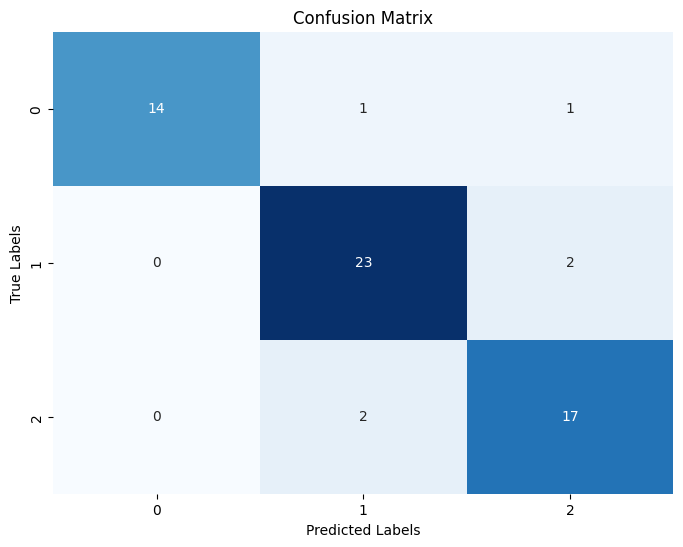

In [212]:
# Evaluación del modelo
import matplotlib.pyplot as plt
import seaborn as sns

y_pred_LR = modelo_LR.predict(X_test_vectorized)
acc_LR = accuracy_score(y_test, y_pred_LR)
cm_LR = confusion_matrix(y_test, y_pred_LR)

print("Precisión Regresión Logística:", acc_LR)
print("Matriz de confusión:\n")
plt.figure(figsize=(8, 6))
sns.heatmap(cm_LR, annot=True, fmt="d", cmap="Blues", cbar=False)
plt.xlabel("Predicted Labels")
plt.ylabel("True Labels")
plt.title("Confusion Matrix")
plt.show()

Muy buena métrica y bajas confusiones. Modelo más que aceptable

In [217]:
#Predicciones
new_phrases = [
    "Cuáles son las reglas principales de Pradera",
    "Año de debut del juego",
    "A cuántos usuarios les gustó el juego?",
]

# Vectorizamos las nuevas frases
new_embeddings = model.encode([phrase.lower() for phrase in new_phrases])

# Hacemos las predicciones
predicciones = modelo_LR.predict(new_embeddings)

# Mapeo inverso (números a etiquetas)
mapeo_inverso = {0: "estadísticas", 1: "información", 2: "relaciones"}
categorias_predichas = [mapeo_inverso[p] for p in predicciones]

# Mostrar resultados
for frase, categoria in zip(new_phrases, categorias_predichas):
    print(f"'{frase}' → {categoria}")

'Cuáles son las reglas principales de Pradera' → relaciones
'Año de debut del juego' → relaciones
'A cuántos usuarios les gustó el juego?' → estadísticas


Vemos una confusión en la primera frase, tendría que haber sido 'información', no 'relaciones'. A continuación hacemos otro modelo a ver si podemos mejorar

###Red Neuronal

In [214]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.utils import to_categorical
from sklearn.model_selection import train_test_split

# Ya tenés los embeddings listos, así que usamos eso:
X = model.encode(df_preguntas["consulta"].str.lower().tolist())  # input: embeddings
y = df_preguntas["categoria_cod"].values                         # labels codificados

# Convertimos las etiquetas a one-hot encoding
y_categorical = to_categorical(y, num_classes=3)

# Split train/test
X_train, X_test, y_train, y_test = train_test_split(X, y_categorical, test_size=0.2, random_state=42)

# Creamos la red neuronal
modelo_NN = Sequential()
modelo_NN.add(Dense(256, activation='relu', input_shape=(X.shape[1],)))
modelo_NN.add(Dropout(0.3))
modelo_NN.add(Dense(128, activation='relu'))
modelo_NN.add(Dropout(0.3))
modelo_NN.add(Dense(3, activation='softmax'))  #3 clases

# Compilamos el modelo
modelo_NN.compile(optimizer='adam', loss='categorical_crossentropy', metrics=['accuracy'])

# Entrenamos el modelo
modelo_NN.fit(X_train, y_train, epochs=30, batch_size=16, validation_data=(X_test, y_test))

Epoch 1/30


/usr/local/lib/python3.11/dist-packages/keras/src/layers/core/dense.py:87: UserWarning:

Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.



15/15 ━━━━━━━━━━━━━━━━━━━━ 2s 26ms/step - accuracy: 0.4346 - loss: 1.0847 - val_accuracy: 0.3333 - val_loss: 1.0533
Epoch 2/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5317 - loss: 1.0032 - val_accuracy: 0.7500 - val_loss: 0.9127
Epoch 3/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 13ms/step - accuracy: 0.7824 - loss: 0.8325 - val_accuracy: 0.7667 - val_loss: 0.7465
Epoch 4/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.7649 - loss: 0.6817 - val_accuracy: 0.8000 - val_loss: 0.5794
Epoch 5/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.8273 - loss: 0.5061 - val_accuracy: 0.8000 - val_loss: 0.5065
Epoch 6/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 12ms/step - accuracy: 0.8663 - loss: 0.4098 - val_accuracy: 0.8500 - val_loss: 0.3574
Epoch 7/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9245 - loss: 0.2908 - val_accuracy: 0.8833 - val_loss: 0.3135
Epoch 8/30
15/15 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.9402 - loss: 0.1987 - val_accuracy: 0.9167 - val_loss: 0.

Con la mitad de las épocas alcanzaba. Se nota que llegó a un tope de accuracy

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step - accuracy: 0.9667 - loss: 0.2665
Precisión de la red neuronal: 0.949999988079071
2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 55ms/step


<Figure size 600x600 with 0 Axes>

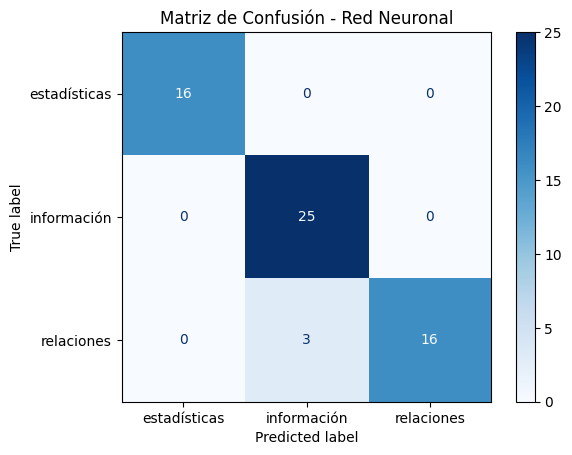

In [215]:
#Evaluamos en el set de prueba
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

loss, accuracy = modelo_NN.evaluate(X_test, y_test)
print("Precisión de la red neuronal:", accuracy)

# Obtener predicciones
y_pred_probs = modelo_NN.predict(X_test)  # salidas con softmax
y_pred_classes = np.argmax(y_pred_probs, axis=1)

# Convertimos y_test one-hot a clases
y_true_classes = np.argmax(y_test, axis=1)

# Etiquetas de clase
labels = ["estadísticas", "información", "relaciones"]

# Matriz de confusión
cm = confusion_matrix(y_true_classes, y_pred_classes)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=labels)

# Mostrar
plt.figure(figsize=(6, 6))
disp.plot(cmap=plt.cm.Blues, values_format='d')
plt.title("Matriz de Confusión - Red Neuronal")
plt.show()

El modelo mejoró en un 5% con respecto al anterior, y se nota en la matriz de confusión: lo hace bastante menos, solo le sigue dando problemas información y relaciones. Es un modelo muy bueno

In [219]:
#Predicciones

def predecir_categoria_nn(frases):
    frases = [f.lower() for f in frases]
    embeddings = model.encode(frases)
    predicciones = modelo_NN.predict(embeddings)
    etiquetas = np.argmax(predicciones, axis=1)
    mapeo_inverso = {0: "estadísticas", 1: "información", 2: "relaciones"}
    categorias_predichas = [mapeo_inverso[p] for p in etiquetas]

    # Mostrar resultados
    for frase, categoria in zip(frases, categorias_predichas):
        print(f"'{frase}' → {categoria}")

predecir_categoria_nn(new_phrases)

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 98ms/step
'cuáles son las reglas principales de pradera' → información
'año de debut del juego' → relaciones
'a cuántos usuarios les gustó el juego?' → información


Ahora predijo bien la primera, pero no la última oración que habíamos probado en el anterior modelo. Veamos algunas queries más:

In [225]:
predecir_categoria_nn(["quien creo el juego","cuantos usuarios juegan","como desempato"])

1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 78ms/step
'quien creo el juego' → relaciones
'cuantos usuarios juegan' → estadísticas
'como desempato' → información


###Conclusión
Conseguí mejores resultados con una red neuronal. Su accuracy (95%) fue de un 5% más alto que la regresión logística (90%), y según las matrices de confusión, el 'mayor desafío' de estos modelos es diferir cuándo las consultas se responden con la información disponible en 'información' o 'relaciones'